<a href="https://colab.research.google.com/github/lcbjrrr/genai/blob/main/GCPMultiAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Multi-Agents


![](https://pbs.twimg.com/media/HISUGUYXQAA5sQS?format=jpg&name=medium)


An AI agent is a type of software system designed to automatically perceive information from its environment, process and reason about that information, and then take actions to achieve a specific goal. It operates by combining inputs (such as data, user requests, or sensor signals), decision-making capabilities (like machine learning models or rules), and outputs (such as responses or actions). A key feature of many modern AI agents is memory, which allows them to store and recall past interactions, context, and results to improve decisions over time and maintain continuity across tasks. Unlike a simple AI model that only generates responses, an AI agent can perform multi-step tasks, use external tools, adapt based on prior experience, and refine its behavior as it works toward an objective. In essence, it acts like a digital assistant or autonomous worker capable of observing, thinking, remembering, and acting to complete tasks with minimal human intervention.


![](https://pbs.twimg.com/media/HISR7ohXIAAb-3E?format=jpg&name=large)

A multi-agent system extends the concept of a single AI agent by involving multiple AI agents that work together (or sometimes independently) to achieve a shared or complex set of goals. Each agent typically has its own capabilities, responsibilities, and even memory, allowing it to specialize in a specific part of a task while communicating and coordinating with other agents. These agents can collaborate, delegate work, exchange information, and adapt based on both their own experiences and interactions with others. By distributing tasks across multiple agents—such as one handling research, another planning, and another executing actions—multi-agent systems can solve more complex problems, scale more efficiently, and mimic team-based workflows similar to human organizations. In essence, a multi-agent system is like a team of digital workers that can observe, think, remember, communicate, and act together to accomplish goals more effectively than a single agent alone.

![](https://pbs.twimg.com/media/HIOIYrGXMAA6Sxa?format=jpg&name=small)

In [ ]:
!pip install fredapi langchain_google_genai

In [ ]:


# @tool
# def get_stock_price(ticker: str) -> float:
#     """Fetches the current real-time market price for any given ticker."""
#     t = yf.Ticker(ticker)
#     return float(t.fast_info['last_price'])

# @tool
# def get_us_mortgage_rate() -> float:
#     """Fetches the most recent USA 30-Year Fixed Rate Mortgage."""
#     series = fred.get_series('MORTGAGE30US')
#     return float(series.iloc[-1])

In [ ]:
import os
import random
import operator
from datetime import datetime
from typing import TypedDict, Dict, List, Annotated, Union

import yfinance as yf
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from IPython.display import Image, display

# =========================================================
# STATE DEFINITION
# =========================================================

class InvestorState(TypedDict):
    selected_ticker: str #eg. AAPL
    cash: float # $ cash ammount
    portfolio: Dict[str, float] # ticker:qty, ticker:qty, 'real_state':value
    stock_history: Dict[str, Dict[str, float]] # ticker:{date:value,date:value}, ticker:{date:value,date:value}
    mortgage_history: Dict[str, float] # date:rate,date:rate
    last_stock_price: float # last stock price for the selected_ticker
    current_stock_price: float # current stock price for the selected_ticker
    current_mortgage_rate: float # current mortgage rate
    buy_signal: bool # buy flag (below 1% decrease)
    sell_signal: bool # sell flag (over 10% raise)
    portfolio_value: float # cash + real_state + stocks

state = {
    "selected_ticker": "AAPL",
    "cash": 999000,
    "portfolio": {"REAL_ESTATE": 0},
    "stock_history": {},
    "mortgage_history": {},
    "last_stock_price": 0,
    "current_stock_price": 0,
    "current_mortgage_rate": 0,
    "buy_signal": False,
    "sell_signal": False,
    "portfolio_value": 0
}
state

{'selected_ticker': 'AAPL',
 'cash': 999000,
 'portfolio': {'REAL_ESTATE': 0},
 'stock_history': {},
 'mortgage_history': {},
 'last_stock_price': 0,
 'current_stock_price': 0,
 'current_mortgage_rate': 0,
 'buy_signal': False,
 'sell_signal': False,
 'portfolio_value': 0}

In [ ]:
def strategy_agent(state: InvestorState):
    llm = ChatGoogleGenerativeAI(model=MODEL)
    prompt = "List the top 5 stock tickers currently in Warren Buffett's portfolio. Return only the tickers separated by commas."

    try:
        response = llm.invoke(prompt)
        buffett_holdings = response.content.strip()
    except Exception as e:
        buffett_holdings = "AAPL, BAC, AXP, KO, CVX"
        print(f"LLM Call failed: {e}")

    print(f"Current Buffett picks (via Gemini): {buffett_holdings}")

    new_ticker = input(f"Choose ticker (Current: {state['selected_ticker']}): ").strip().upper()

    if new_ticker and new_ticker != state["selected_ticker"]:
        return {
            "selected_ticker": new_ticker,
            "last_stock_price": 0.0,
            "current_stock_price": 0.0
            # Note: We don't wipe stock_history here anymore to preserve other tickers
        }
    return {}
strategy_agent(state)

Current Buffett picks (via Gemini): AAPL,BAC,AXP,KO,CVX
Choose ticker (Current: AAPL): 


{}

In [ ]:
def macro_monitor(state: InvestorState):
#   series = fred.get_series('MORTGAGE30US')
#   return float(series.iloc[-1])
    rate = random.uniform(4.0, 7.0)
    now = datetime.now().isoformat()
    return {"mortgage_history": {**state["mortgage_history"], now: rate},
        "current_mortgage_rate": rate}
macro_monitor(state)

{'mortgage_history': {'2026-05-13T18:43:53.770284': 6.755248486990166},
 'current_mortgage_rate': 6.755248486990166}

In [ ]:
def stock_monitor(state: InvestorState):
    ticker = state["selected_ticker"]
#   t = yf.Ticker(ticker)
#   return float(t.fast_info['last_price'])
    price = random.uniform(220, 260)
    now = datetime.now().isoformat()
    current_history = state["stock_history"].copy()
    ticker_history = current_history.get(ticker, {}).copy()
    ticker_history[now] = price
    current_history[ticker] = ticker_history
    return {"stock_history": current_history,
        "last_stock_price": state["current_stock_price"],
        "current_stock_price": price}
stock_monitor(state)


{'stock_history': {'AAPL': {'2026-05-13T18:43:53.782911': 228.1143687444108}},
 'last_stock_price': 0,
 'current_stock_price': 228.1143687444108}

In [ ]:
PCT_INCREASE_SELL = 10
PCT_DECREASE_BUY = -1
def trading_agent(state: InvestorState):
    old, new = state["last_stock_price"], state["current_stock_price"]
    buy, sell = False, False
    if old != 0:
        change = ((new - old) / old) * 100
        print(f"Price Change for {state['selected_ticker']} ${new:.2f}: {change:.1f}%")
        if change <= PCT_DECREASE_BUY: buy = True
        elif change >= PCT_INCREASE_SELL: sell = True
    return {"buy_signal": buy, "sell_signal": sell}
trading_agent(state)

{'buy_signal': False, 'sell_signal': False}

In [ ]:
def buy_agent(state: InvestorState):
    qty_input = input(f"Signal detected! Buy how many {state['selected_ticker']}? ")
    qty = int(qty_input) if qty_input.isdigit() else 0
    cost = qty * state["current_stock_price"]
    if cost > state["cash"]:
        print("Insufficient cash.")
        return {}
    new_portfolio = state["portfolio"].copy()
    new_portfolio[state["selected_ticker"]] = new_portfolio.get(state["selected_ticker"], 0) + qty
    return {"cash": state["cash"] - cost, "portfolio": new_portfolio}
buy_agent(state)

Signal detected! Buy how many AAPL? 


{'cash': 999000, 'portfolio': {'REAL_ESTATE': 0, 'AAPL': 0}}

In [ ]:
def sell_agent(state: InvestorState):
    shares = state["portfolio"].get(state["selected_ticker"], 0)
    if shares > 0:
        gain = shares * state["current_stock_price"]
        new_portfolio = state["portfolio"].copy()
        new_portfolio[state["selected_ticker"]] = 0
        print(f"Sold all {state['selected_ticker']} shares for ${gain:,.2f}")
        return {"cash": state["cash"] + gain, "portfolio": new_portfolio}
    return {}
sell_agent(state)

{}

In [ ]:
MORTGAGE_RATE_BUY = 5.0
BUY_HOUSE_CASH_PCT=0.5
def house_agent(state: InvestorState):
    print(state["current_mortgage_rate"],state["current_mortgage_rate"] < MORTGAGE_RATE_BUY,'.......',   state['buy_signal'] , state['sell_signal'])
    if state["current_mortgage_rate"] < MORTGAGE_RATE_BUY and not state['buy_signal'] and not state['sell_signal']:
        investment = state["cash"] * BUY_HOUSE_CASH_PCT
        new_portfolio = state["portfolio"].copy()
        new_portfolio["REAL_ESTATE"] = new_portfolio.get("REAL_ESTATE", 0) + investment
        print(f"Low rates! Invested ${investment:,.2f} in Real Estate.")
        return {"cash": state["cash"] - investment, "portfolio": new_portfolio}
    return {}

house_agent(state)

0 True ....... False False
Low rates! Invested $499,500.00 in Real Estate.


{'cash': 499500.0, 'portfolio': {'REAL_ESTATE': 499500.0}}

In [ ]:
def portfolio_agent(state: InvestorState):
    stock_value = 0
    for asset, shares in state["portfolio"].items():
        if asset == "REAL_ESTATE": continue
        stock_value += (shares * state["current_stock_price"])
    house_value = state["portfolio"].get("REAL_ESTATE", 0)
    total = (state["cash"] + stock_value + house_value)
    print("\n=== PORTFOLIO ===")
    print(f"Total: ${total:,.0f} | Cash: ${state['cash']:,.0f} | House: ${house_value:,.0f} | Stocks: ${stock_value:,.0f}", ':' , state["portfolio"])
    print(state['stock_history'])
    print(state['mortgage_history'])
    return {"portfolio_value": total}
portfolio_agent(state)


=== PORTFOLIO ===
Total: $999,000 | Cash: $499,500 | House: $499,500 | Stocks: $0 : {'REAL_ESTATE': 499500.0}
{'AAPL': {'2026-05-13T18:44:01.138391': 220.08978156576518}}
{'2026-05-13T18:44:01.135546': 4.231704478231081}


{'portfolio_value': 999000.0}

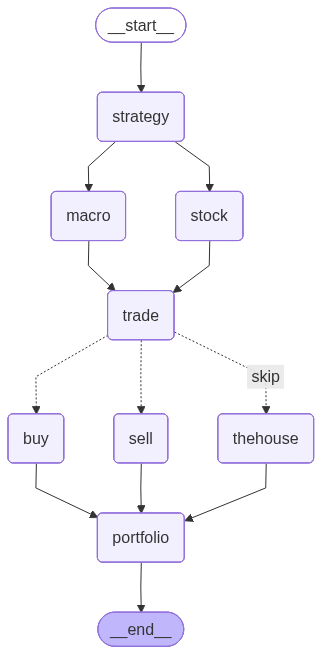

In [ ]:

def buy_sell_router(state: InvestorState):
    if state["buy_signal"]: return "buy"
    if state["sell_signal"]: return "sell"
    return "skip"

builder = StateGraph(InvestorState)

builder.add_node("strategy", strategy_agent)
builder.add_node("stock", stock_monitor)
builder.add_node("macro", macro_monitor)
builder.add_node("trade", trading_agent)
builder.add_node("buy", buy_agent)
builder.add_node("sell", sell_agent)
builder.add_node("thehouse", house_agent)
builder.add_node("portfolio", portfolio_agent)

builder.set_entry_point("strategy")

builder.add_edge("strategy", "stock")
builder.add_edge("strategy", "macro")
builder.add_edge("stock", "trade")
builder.add_edge("macro", "trade")
builder.add_edge("trade", "thehouse")

builder.add_conditional_edges(
    "trade",
    buy_sell_router,
    {"buy": "buy", "sell": "sell", "skip": "thehouse"}
)

builder.add_edge("buy", "portfolio")
builder.add_edge("sell", "portfolio")
builder.add_edge("thehouse", "portfolio")
builder.add_edge("portfolio", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:


state['selected_ticker']='AAPL'
if __name__ == "__main__":
    while True and state['selected_ticker']!='EXIT':
        print("\n==============================")
        print(" RUNNING FULL LANGGRAPH CYCLE")
        print("==============================")
        state = graph.invoke(state)
        SEC=5*2
        print(f"\nSleeping {SEC} seconds...\n")
        time.sleep(SEC)
    print("\n==============================")
    print(" *** THE END ***")
    print("==============================")


 RUNNING FULL LANGGRAPH CYCLE
Current Buffett picks (via Gemini): AAPL,BAC,AXP,KO,CVX
Choose ticker (Current: AAPL): 
Price Change for AAPL $234.69: 6.6%
4.829699408828644 True ....... False False
Low rates! Invested $249,750.00 in Real Estate.

=== PORTFOLIO ===
Total: $999,000 | Cash: $249,750 | House: $749,250 | Stocks: $0 : {'REAL_ESTATE': 749250.0}
{'AAPL': {'2026-05-13T18:44:01.138391': 220.08978156576518, '2026-05-13T18:45:31.390726': 234.6908473647688}}

Sleeping 10 seconds...


 RUNNING FULL LANGGRAPH CYCLE
Current Buffett picks (via Gemini): AAPL,BAC,AXP,KO,CVX
Choose ticker (Current: AAPL): 
Price Change for AAPL $236.22: 0.7%
4.890773503478485 True ....... False False
Low rates! Invested $124,875.00 in Real Estate.

=== PORTFOLIO ===
Total: $999,000 | Cash: $124,875 | House: $874,125 | Stocks: $0 : {'REAL_ESTATE': 874125.0}
{'AAPL': {'2026-05-13T18:44:01.138391': 220.08978156576518, '2026-05-13T18:45:31.390726': 234.6908473647688, '2026-05-13T18:45:49.488324': 236.21716344



```

!pip install fredapi langchain_google_genai


MODEL="gemini-2.5-flash"

# @tool
# def get_stock_price(ticker: str) -> float:
#     """Fetches the current real-time market price for any given ticker."""
#     t = yf.Ticker(ticker)
#     return float(t.fast_info['last_price'])

# @tool
# def get_us_mortgage_rate() -> float:
#     """Fetches the most recent USA 30-Year Fixed Rate Mortgage."""
#     series = fred.get_series('MORTGAGE30US')
#     return float(series.iloc[-1])

import os
import random
import operator
from datetime import datetime
from typing import TypedDict, Dict, List, Annotated, Union

import yfinance as yf
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from IPython.display import Image, display

# =========================================================
# STATE DEFINITION
# =========================================================

class InvestorState(TypedDict):
    selected_ticker: str #eg. AAPL
    cash: float # $ cash ammount
    portfolio: Dict[str, float] # ticker:qty, ticker:qty, 'real_state':value
    stock_history: Dict[str, Dict[str, float]] # ticker:{date:value,date:value}, ticker:{date:value,date:value}
    mortgage_history: Dict[str, float] # date:rate,date:rate
    last_stock_price: float # last stock price for the selected_ticker
    current_stock_price: float # current stock price for the selected_ticker
    current_mortgage_rate: float # current mortgage rate
    buy_signal: bool # buy flag (below 1% decrease)
    sell_signal: bool # sell flag (over 10% raise)
    portfolio_value: float # cash + real_state + stocks

state = {
    "selected_ticker": "AAPL",
    "cash": 999000,
    "portfolio": {"REAL_ESTATE": 0},
    "stock_history": {},
    "mortgage_history": {},
    "last_stock_price": 0,
    "current_stock_price": 0,
    "current_mortgage_rate": 0,
    "buy_signal": False,
    "sell_signal": False,
    "portfolio_value": 0
}
state

def strategy_agent(state: InvestorState):
    llm = ChatGoogleGenerativeAI(model=MODEL)
    prompt = "List the top 5 stock tickers currently in Warren Buffett's portfolio. Return only the tickers separated by commas."

    try:
        response = llm.invoke(prompt)
        buffett_holdings = response.content.strip()
    except Exception as e:
        buffett_holdings = "AAPL, BAC, AXP, KO, CVX"
        print(f"LLM Call failed: {e}")

    print(f"Current Buffett picks (via Gemini): {buffett_holdings}")

    new_ticker = input(f"Choose ticker (Current: {state['selected_ticker']}): ").strip().upper()

    if new_ticker and new_ticker != state["selected_ticker"]:
        return {
            "selected_ticker": new_ticker,
            "last_stock_price": 0.0,
            "current_stock_price": 0.0
            # Note: We don't wipe stock_history here anymore to preserve other tickers
        }
    return {}
strategy_agent(state)

def macro_monitor(state: InvestorState):
#   series = fred.get_series('MORTGAGE30US')
#   return float(series.iloc[-1])
    rate = random.uniform(4.0, 7.0)
    now = datetime.now().isoformat()
    return {"mortgage_history": {**state["mortgage_history"], now: rate},
        "current_mortgage_rate": rate}
macro_monitor(state)

def stock_monitor(state: InvestorState):
    ticker = state["selected_ticker"]
#   t = yf.Ticker(ticker)
#   return float(t.fast_info['last_price'])
    price = random.uniform(220, 260)
    now = datetime.now().isoformat()
    current_history = state["stock_history"].copy()
    ticker_history = current_history.get(ticker, {}).copy()
    ticker_history[now] = price
    current_history[ticker] = ticker_history
    return {"stock_history": current_history,
        "last_stock_price": state["current_stock_price"],
        "current_stock_price": price}
stock_monitor(state)

PCT_INCREASE_SELL = 10
PCT_DECREASE_BUY = -1
def trading_agent(state: InvestorState):
    old, new = state["last_stock_price"], state["current_stock_price"]
    buy, sell = False, False
    if old != 0:
        change = ((new - old) / old) * 100
        print(f"Price Change for {state['selected_ticker']} ${new:.2f}: {change:.1f}%")
        if change <= PCT_DECREASE_BUY: buy = True
        elif change >= PCT_INCREASE_SELL: sell = True
    return {"buy_signal": buy, "sell_signal": sell}
trading_agent(state)

def buy_agent(state: InvestorState):
    qty_input = input(f"Signal detected! Buy how many {state['selected_ticker']}? ")
    qty = int(qty_input) if qty_input.isdigit() else 0
    cost = qty * state["current_stock_price"]
    if cost > state["cash"]:
        print("Insufficient cash.")
        return {}
    new_portfolio = state["portfolio"].copy()
    new_portfolio[state["selected_ticker"]] = new_portfolio.get(state["selected_ticker"], 0) + qty
    return {"cash": state["cash"] - cost, "portfolio": new_portfolio}
buy_agent(state)

def sell_agent(state: InvestorState):
    shares = state["portfolio"].get(state["selected_ticker"], 0)
    if shares > 0:
        gain = shares * state["current_stock_price"]
        new_portfolio = state["portfolio"].copy()
        new_portfolio[state["selected_ticker"]] = 0
        print(f"Sold all {state['selected_ticker']} shares for ${gain:,.2f}")
        return {"cash": state["cash"] + gain, "portfolio": new_portfolio}
    return {}
sell_agent(state)

MORTGAGE_RATE_BUY = 5.0
BUY_HOUSE_CASH_PCT=0.5
def house_agent(state: InvestorState):
    print(state["current_mortgage_rate"],state["current_mortgage_rate"] < MORTGAGE_RATE_BUY,'.......',   state['buy_signal'] , state['sell_signal'])
    if state["current_mortgage_rate"] < MORTGAGE_RATE_BUY and not state['buy_signal'] and not state['sell_signal']:
        investment = state["cash"] * BUY_HOUSE_CASH_PCT
        new_portfolio = state["portfolio"].copy()
        new_portfolio["REAL_ESTATE"] = new_portfolio.get("REAL_ESTATE", 0) + investment
        print(f"Low rates! Invested ${investment:,.2f} in Real Estate.")
        return {"cash": state["cash"] - investment, "portfolio": new_portfolio}
    return {}

house_agent(state)

def portfolio_agent(state: InvestorState):
    stock_value = 0
    for asset, shares in state["portfolio"].items():
        if asset == "REAL_ESTATE": continue
        stock_value += (shares * state["current_stock_price"])
    house_value = state["portfolio"].get("REAL_ESTATE", 0)
    total = (state["cash"] + stock_value + house_value)
    print("\n=== PORTFOLIO ===")
    print(f"Total: ${total:,.0f} | Cash: ${state['cash']:,.0f} | House: ${house_value:,.0f} | Stocks: ${stock_value:,.0f}", ':' , state["portfolio"])
    print(state['stock_history'])
    print(state['mortgage_history'])
    return {"portfolio_value": total}
portfolio_agent(state)

def buy_sell_router(state: InvestorState):
    if state["buy_signal"]: return "buy"
    if state["sell_signal"]: return "sell"
    return "skip"

builder = StateGraph(InvestorState)

builder.add_node("strategy", strategy_agent)
builder.add_node("stock", stock_monitor)
builder.add_node("macro", macro_monitor)
builder.add_node("trade", trading_agent)
builder.add_node("buy", buy_agent)
builder.add_node("sell", sell_agent)
builder.add_node("thehouse", house_agent)
builder.add_node("portfolio", portfolio_agent)

builder.set_entry_point("strategy")

builder.add_edge("strategy", "stock")
builder.add_edge("strategy", "macro")
builder.add_edge("stock", "trade")
builder.add_edge("macro", "trade")
builder.add_edge("trade", "thehouse")

builder.add_conditional_edges(
    "trade",
    buy_sell_router,
    {"buy": "buy", "sell": "sell", "skip": "thehouse"}
)

builder.add_edge("buy", "portfolio")
builder.add_edge("sell", "portfolio")
builder.add_edge("thehouse", "portfolio")
builder.add_edge("portfolio", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

state['selected_ticker']='AAPL'
if __name__ == "__main__":
    while True and state['selected_ticker']!='EXIT':
        print("\n==============================")
        print(" RUNNING FULL LANGGRAPH CYCLE")
        print("==============================")
        state = graph.invoke(state)
        SEC=5*2
        print(f"\nSleeping {SEC} seconds...\n")
        time.sleep(SEC)
    print("\n==============================")
    print(" *** THE END ***")
    print("==============================")


```





```
import os
import random
import operator
from datetime import datetime
from typing import TypedDict, Dict, List, Annotated, Union

import yfinance as yf
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from IPython.display import Image, display

# =========================================================
# STATE DEFINITION
# =========================================================

class InvestorState(TypedDict):
    selected_ticker: str
    cash: float
    portfolio: Dict[str, float]
    stock_history: Dict[str, float]
    mortgage_history: Dict[str, float]
    last_stock_price: float
    current_stock_price: float
    current_mortgage_rate: float
    buy_signal: bool
    sell_signal: bool
    portfolio_value: float

# =========================================================
# NODES
# =========================================================

def strategy_agent(state: InvestorState):
    llm = ChatGoogleGenerativeAI(model=MODEL)
    prompt = "List the top 5 stock tickers currently in Warren Buffett's portfolio. Return only the tickers separated by commas."
    try:
        response = llm.invoke(prompt)
        buffett_holdings = response.content.strip()
    except Exception as e:
        buffett_holdings = "AAPL, BAC, AXP, KO, CVX (Fallback)"
        print(f"LLM Call failed: {e}")
    print(f"Current Buffett picks (via Gemini): {buffett_holdings}")
    new_ticker = input(f"Choose ticker (Current: {state['selected_ticker']}): ").strip().upper()
    
    if new_ticker and new_ticker != state["selected_ticker"]:
        return {
            "selected_ticker": new_ticker,
            "last_stock_price": 0.0,
            "current_stock_price": 0.0,
            "stock_history": {}
        }
    return {}

# =========================================================
# REMAINING NODES (Unchanged)
# =========================================================

def stock_monitor(state: InvestorState):
    ticker = state["selected_ticker"]
    price = random.uniform(220, 260)
    now = datetime.now().isoformat()
    return {
        "stock_history": {**state["stock_history"], now: price},
        "last_stock_price": state["current_stock_price"],
        "current_stock_price": price
    }

def macro_monitor(state: InvestorState):
    rate = random.uniform(4.0, 7.0)
    now = datetime.now().isoformat()
    return {
        "mortgage_history": {**state["mortgage_history"], now: rate},
        "current_mortgage_rate": rate
    }

def trading_agent(state: InvestorState):
    old, new = state["last_stock_price"], state["current_stock_price"]
    buy, sell = False, False
    if old != 0:
        change = ((new - old) / old) * 100
        print(f"Price Change: {change:.2f}%")
        if change <= -1.0: buy = True
        elif change >= 10.0: sell = True
        
    return {"buy_signal": buy, "sell_signal": sell}

def buy_agent(state: InvestorState):
    qty_input = input(f"Signal detected! Buy how many {state['selected_ticker']}? ")
    qty = int(qty_input) if qty_input.isdigit() else 0
    cost = qty * state["current_stock_price"]    
    if cost > state["cash"]:
        print("Insufficient cash.")
        return {}
    new_portfolio = state["portfolio"].copy()
    new_portfolio[state["selected_ticker"]] = new_portfolio.get(state["selected_ticker"], 0) + qty
    return {"cash": state["cash"] - cost, "portfolio": new_portfolio}

def sell_agent(state: InvestorState):
    shares = state["portfolio"].get(state["selected_ticker"], 0)
    if shares > 0:
        gain = shares * state["current_stock_price"]
        new_portfolio = state["portfolio"].copy()
        new_portfolio[state["selected_ticker"]] = 0
        print(f"Sold all shares for ${gain:,.2f}")
        return {"cash": state["cash"] + gain, "portfolio": new_portfolio}
    return {}

def house_agent(state: InvestorState):
    if state["current_mortgage_rate"] < 5.0 and not state['buy_signal'] and not state['sell_signal']:
        investment = state["cash"] * 0.5
        new_portfolio = state["portfolio"].copy()
        new_portfolio["REAL_ESTATE"] = new_portfolio.get("REAL_ESTATE", 0) + investment
        print(f"Low rates! Invested ${investment:,.2f} in Real Estate.")
        return {"cash": state["cash"] - investment, "portfolio": new_portfolio}
    return {}

def portfolio_agent(state: InvestorState):
    stock_value = 0
    for asset, shares in state["portfolio"].items():
        if asset == "REAL_ESTATE": continue
        stock_value += (shares * state["current_stock_price"])

    house_value = state["portfolio"].get("REAL_ESTATE", 0)
    total = (state["cash"] + stock_value + house_value)
    
    print("\n=== PORTFOLIO ===")
    print(f"Total: ${total:,.0f} | Cash: ${state['cash']:,.0f} | House: ${house_value:,.0f} | Stocks: ${stock_value:,.0f}", ':' , state["portfolio"])
    print(state['stock_history'])
    return {"portfolio_value": total}

# =========================================================
# ROUTER & GRAPH (Structure Preserved)
# =========================================================

def buy_sell_router(state: InvestorState):
    if state["buy_signal"]: return "buy"
    if state["sell_signal"]: return "sell"
    return "skip"

builder = StateGraph(InvestorState)

builder.add_node("strategy", strategy_agent)
builder.add_node("stock", stock_monitor)
builder.add_node("macro", macro_monitor)
builder.add_node("trade", trading_agent)
builder.add_node("buy", buy_agent)
builder.add_node("sell", sell_agent)
builder.add_node("thehouse", house_agent)
builder.add_node("portfolio", portfolio_agent)

builder.set_entry_point("strategy")

builder.add_edge("strategy", "stock")
builder.add_edge("strategy", "macro")
builder.add_edge("stock", "trade")
builder.add_edge("macro", "trade")
builder.add_edge("trade", "thehouse")

builder.add_conditional_edges(
    "trade",
    buy_sell_router,
    {
        "buy": "buy",
        "sell": "sell",
        "skip": "thehouse"
    }
)

builder.add_edge("buy", "portfolio")
builder.add_edge("sell", "portfolio")
builder.add_edge("thehouse", "portfolio")
builder.add_edge("portfolio", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
```



In [ ]:
!pip install langchain_anthropic

In [ ]:
"""
AAPL Stock Monitor Agent — LangGraph edition
=============================================
Monitors Apple (AAPL) every 5 minutes using a LangGraph
StateGraph with explicit nodes and edges, backed by Claude
(claude-sonnet-4-20250514).

- BUY alert  → price drops ≥ 1 % from reference
- SELL alert → price rises ≥ 10 % from reference

Dependencies:
    pip install langgraph langchain-anthropic langchain-core yfinance

Usage:
    export ANTHROPIC_API_KEY="sk-..."
    python aapl_agent_langgraph.py
"""

import os

import time
from datetime import datetime
from typing import Literal, TypedDict

import yfinance as yf
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode

# ── Configuration ─────────────────────────────────────────────────────────────
TICKER         = "AAPL"
CHECK_INTERVAL = 5 * 2   # seconds
BUY_THRESHOLD  = -0.01    # −1 %
SELL_THRESHOLD = 0.10     # +10 %


# ── Graph state ───────────────────────────────────────────────────────────────

class AgentState(TypedDict):
    """Everything that flows through the graph nodes each cycle."""
    messages: list          # full conversation / tool-call history
    reference_price: float | None
    current_price: float | None
    action: str | None


# ── Tools ─────────────────────────────────────────────────────────────────────

@tool
def get_stock_price(ticker: str) -> str:
    """Fetch the latest market price for a stock ticker from Yahoo Finance."""
    data = yf.download(ticker, period="1d", interval="1m", progress=False)
    if data.empty:
        return f"ERROR: no data returned for {ticker}"
    price = float(data["Close"].iloc[-1])
    return str(price)


@tool
def send_alert(
    action: str,
    ticker: str,
    current_price: float,
    reference_price: float,
    change_pct: float,
    reason: str,
) -> str:
    """
    Send a trading alert. action must be 'BUY', 'SELL', or 'HOLD'.
    change_pct is the percentage change (e.g. -1.5 means −1.5%).
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    border = "=" * 60
    colors = {"BUY": "\033[92m", "SELL": "\033[91m", "HOLD": "\033[93m"}
    arrows = {"BUY": "📉", "SELL": "📈", "HOLD": "➡️"}
    reset  = "\033[0m"

    clr   = colors.get(action, reset)
    arrow = arrows.get(action, "")

    print(
        f"\n{border}\n"
        f"{clr}🔔  {action} ALERT  {arrow}{reset}\n"
        f"  Ticker    : {ticker}\n"
        f"  Time      : {timestamp}\n"
        f"  Ref price : ${reference_price:.2f}\n"
        f"  Now       : ${current_price:.2f}\n"
        f"  Change    : {change_pct:+.2f}%\n"
        f"  Reason    : {reason}\n"
        f"{border}\n"
    )
    return f"Alert dispatched: {action} {ticker} @ ${current_price:.2f}"


tools = [get_stock_price, send_alert]

# ── LLM bound to tools ────────────────────────────────────────────────────────

llm = ChatAnthropic(model="claude-sonnet-4-6", max_tokens=1024)
llm_with_tools = llm.bind_tools(tools)


# ── Graph nodes ───────────────────────────────────────────────────────────────

def analyst_node(state: AgentState) -> AgentState:
    """
    The LLM node — receives the current state, decides which tool(s) to call,
    and appends its response to the message list.
    """
    response = llm_with_tools.invoke(state["messages"])
    return {**state, "messages": state["messages"] + [response]}


def extract_results_node(state: AgentState) -> AgentState:
    """
    Post-processing node — walks the message history to pull out the
    fetched price and chosen action so they live in typed state fields.
    """
    current_price = state.get("current_price")
    action = state.get("action")

    for msg in state["messages"]:
        # ToolMessage content holds the raw tool return value
        if isinstance(msg, ToolMessage):
            content = msg.content or ""
            # get_stock_price returns a plain float string
            try:
                current_price = float(content.strip())
            except ValueError:
                pass
            # send_alert return contains the action word
            for word in ["BUY", "SELL", "HOLD"]:
                if word in content:
                    action = word
                    break

    return {**state, "current_price": current_price, "action": action}


# ── Routing logic (conditional edge) ─────────────────────────────────────────

def should_continue(state: AgentState) -> Literal["tools", "extract"]:
    """
    If the last AI message has tool calls pending → execute them.
    Otherwise → move to the extract node and finish.
    """
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and last.tool_calls:
        return "tools"
    return "extract"


# ── Build the StateGraph ──────────────────────────────────────────────────────

tool_node = ToolNode(tools)  # LangGraph built-in: runs all tool calls in the message

graph_builder = StateGraph(AgentState)

graph_builder.add_node("analyst",  analyst_node)
graph_builder.add_node("tools",    tool_node)
graph_builder.add_node("extract",  extract_results_node)

graph_builder.add_edge(START,      "analyst")
graph_builder.add_conditional_edges("analyst", should_continue)
graph_builder.add_edge("tools",    "analyst")   # loop back after tool execution
graph_builder.add_edge("extract",  END)

graph = graph_builder.compile()


# ── Single monitoring cycle ───────────────────────────────────────────────────

def run_cycle(reference_price: float | None) -> float:
    ref_str = f"${reference_price:.2f}" if reference_price else "N/A (first run — establish baseline, HOLD)"

    system = SystemMessage(content=(
        "You are a stock-monitoring agent.\n"
        f"1. Call get_stock_price('{TICKER}') to get the current price.\n"
        f"2. Compare it to the reference price.\n"
        f"   Drop ≥ {abs(BUY_THRESHOLD)*100:.0f}% → send_alert action='BUY'\n"
        f"   Rise ≥ {SELL_THRESHOLD*100:.0f}% → send_alert action='SELL'\n"
        "   Otherwise → send_alert action='HOLD'\n"
        "3. On first run (no reference) → HOLD.\n"
        "Always call send_alert exactly once."
    ))
    human = HumanMessage(content=(
        f"Check {TICKER}. Reference price: {ref_str}. "
        f"BUY threshold: -{abs(BUY_THRESHOLD)*100:.0f}%, "
        f"SELL threshold: +{SELL_THRESHOLD*100:.0f}%."
    ))

    initial_state: AgentState = {
        "messages": [system, human],
        "reference_price": reference_price,
        "current_price": None,
        "action": None,
    }

    final_state = graph.invoke(initial_state)
    return final_state["current_price"] or reference_price or 0.0


# ── Main monitoring loop ──────────────────────────────────────────────────────

def main() -> None:
    print("🤖  AAPL Stock Monitor Agent  (LangGraph + Claude)")
    print(f"    Interval : every {CHECK_INTERVAL // 60} min")
    print(f"    BUY at   : price drops ≥ {abs(BUY_THRESHOLD)*100:.0f}%")
    print(f"    SELL at  : price rises ≥ {SELL_THRESHOLD*100:.0f}%")
    print("    Ctrl-C to stop.\n")

    reference_price: float | None = None

    while True:
        try:
            ts = datetime.now().strftime("%H:%M:%S")
            print(f"[{ts}] Running graph cycle…")
            reference_price = run_cycle(reference_price)
            ts = datetime.now().strftime("%H:%M:%S")
            print(f"[{ts}] Cycle complete. Next check in {CHECK_INTERVAL // 60} min.\n")
        except KeyboardInterrupt:
            print("\n👋  Agent stopped.")
            break
        except Exception as exc:
            print(f"⚠️  Cycle error: {exc}")

        time.sleep(CHECK_INTERVAL)


if __name__ == "__main__":
    main()

🤖  AAPL Stock Monitor Agent  (LangGraph + Claude)
    Interval : every 0 min
    BUY at   : price drops ≥ 1%
    SELL at  : price rises ≥ 10%
    Ctrl-C to stop.

[23:47:41] Running graph cycle…


/tmp/ipykernel_114628/3139817469.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1d", interval="1m", progress=False)
/tmp/ipykernel_114628/3139817469.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(data["Close"].iloc[-1])


⚠️  Cycle error: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.0.content.0: unexpected `tool_use_id` found in `tool_result` blocks: toolu_012HAj8b5BbWnxaE22aL1JGm. Each `tool_result` block must have a corresponding `tool_use` block in the previous message.'}, 'request_id': 'req_011Cb1ThgALLrBaiWXvpnGjb'}
[23:47:54] Running graph cycle…


/tmp/ipykernel_114628/3139817469.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1d", interval="1m", progress=False)
/tmp/ipykernel_114628/3139817469.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(data["Close"].iloc[-1])


⚠️  Cycle error: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.0.content.0: unexpected `tool_use_id` found in `tool_result` blocks: toolu_013LDjcrMnVwWN3q9x9TTBmV. Each `tool_result` block must have a corresponding `tool_use` block in the previous message.'}, 'request_id': 'req_011Cb1TiabVe8fpsgyCRJFse'}
[23:48:06] Running graph cycle…


/tmp/ipykernel_114628/3139817469.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1d", interval="1m", progress=False)
/tmp/ipykernel_114628/3139817469.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(data["Close"].iloc[-1])


⚠️  Cycle error: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.0.content.0: unexpected `tool_use_id` found in `tool_result` blocks: toolu_01Dr6Gk7PRS8tEtw1Nhh3cSS. Each `tool_result` block must have a corresponding `tool_use` block in the previous message.'}, 'request_id': 'req_011Cb1TjZ5zbPnQ4FQBXpuxj'}
[23:48:19] Running graph cycle…


/tmp/ipykernel_114628/3139817469.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1d", interval="1m", progress=False)
/tmp/ipykernel_114628/3139817469.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(data["Close"].iloc[-1])


⚠️  Cycle error: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.0.content.0: unexpected `tool_use_id` found in `tool_result` blocks: toolu_018g82CeaahPEW5EmJkCB57x. Each `tool_result` block must have a corresponding `tool_use` block in the previous message.'}, 'request_id': 'req_011Cb1TkVNXTuqfR6mHkvd2h'}


KeyboardInterrupt: 

![](https://pbs.twimg.com/media/HIOIxB8WUAAH1hg?format=jpg&name=large)

![](https://pbs.twimg.com/media/HIOI51zXsAAZqjM?format=jpg&name=large)